In [1]:
import os
os.chdir(r"E:\MyAIProject") # workspace
from LinLanAIFrame import *
from LinLanAIFrame.load_pretrain_models import get_model_path

In [2]:
def image_preprocessing(file_path: str):
    image = Image.open(file_path).convert('RGB')
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    return transform(image).unsqueeze(0)

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
def init_model(model_name, download_path="./"):
    global device
    model_id, config_path, state_dict_path = get_model_path(model_name, download_path=download_path)
    model = init_model_from_config_state_dict(config_path=config_path, state_dict_path=state_dict_path, strict=False)
    for param in model.parameters():
        param.requires_grad = False
    model = model.to(device)
    model = model.eval()
    return model
model = init_model("vae-x8")
print("Using device:", device)

文件已经存在, File Exists: ./pretrain/state_dict/003e2ba889653274bde0f086f5c318c3.pth
文件已经存在, File Exists: ./pretrain/config/003e2ba889653274bde0f086f5c318c3.json
Using device: cuda


In [4]:
data = image_preprocessing("./test_data/clip/A red Ferrari sports car parked in a city parking lot at night, with lit buildings in the background.jpg").to(device)

In [5]:
with torch.no_grad(), autocast():
    latent = model.image2latent(data)
    decode = model.latent2image(latent).clamp(min=-1, max=1)

In [6]:
image_show = data[0].cpu().permute(1,2,0).numpy()/2 + 0.5
latent_show = latent[0].cpu().permute(1,2,0).numpy()[:, :, :3]
decode_show = (decode[0].cpu().permute(1,2,0).numpy()/2 + 0.5).astype(np.float32)

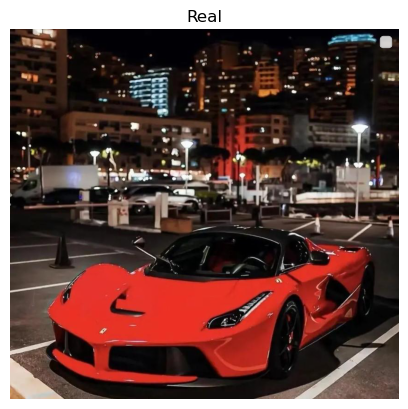

In [7]:
plt.imshow(image_show)
plt.title("Real")
plt.axis("off")
plt.legend()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-23.5312..20.984402].


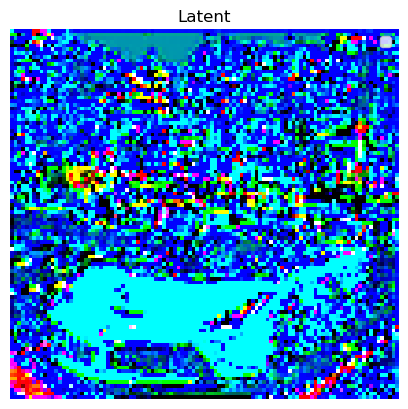

In [8]:
plt.imshow(latent_show)
plt.title("Latent")
plt.axis("off")
plt.legend()
plt.show()

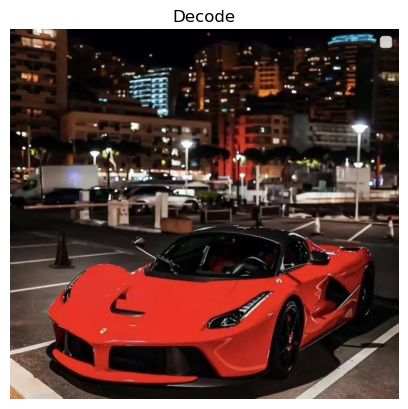

In [9]:
plt.imshow(decode_show)
plt.title("Decode")
plt.axis("off")
plt.legend()
plt.show()

In [10]:
quit()